# TP 3 - ACP des Boissons

## Analyse en composantes principales complete

- matrice `R`
- valeurs propres et leur representation
- tableau complet des taux d'inertie
- projections des individus
- representation des individus
- qualites et contributions des individus
- nouvelles variables et leurs representations dans le nouveau plan
- interpretations axe par axe
- caracterisation des boissons et points communs entre elles


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 115, "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

racine = Path.cwd()
dossier_sortie = racine / "outputs_tp3_boissons"
dossier_sortie.mkdir(parents=True, exist_ok=True)

print(f"Dossier de sortie : {dossier_sortie}")

Dossier de sortie : /outputs_tp3_boissons


## 1. Donnees brutes

In [2]:
boissons = [f"Boisson {k}" for k in range(1, 11)]
variables = [
    "Fruite", "Sucre", "Gout", "Amer", "Piquant",
    "Rugosite", "Odeur", "Acide", "Parfume", "Suffocant"
]
variables_court = ["Frut", "Sucr", "Gout", "Amer", "Piq", "Rugo", "Odeur", "Acid", "Parf", "Suff"]

donnees = [
    [2.29, 2.86, 2.86, 3.29, 3.29, 3.00, 3.14, 4.29, 2.29, 0.54],
    [1.14, 1.79, 3.86, 3.57, 3.57, 3.00, 3.43, 3.71, 1.43, 0.93],
    [2.71, 4.14, 1.86, 3.57, 3.14, 2.43, 3.71, 3.57, 3.29, 0.64],
    [4.14, 4.71, 2.00, 3.07, 2.29, 2.57, 4.00, 3.14, 4.14, 0.00],
    [1.29, 2.29, 3.86, 4.14, 2.86, 3.17, 4.43, 3.86, 2.14, 1.50],
    [0.00, 1.86, 4.29, 4.79, 2.71, 3.57, 4.14, 3.86, 1.14, 0.64],
    [3.86, 4.71, 1.57, 2.57, 2.00, 2.71, 3.43, 4.21, 3.57, 0.50],
    [0.00, 0.00, 2.86, 3.86, 2.71, 3.00, 4.14, 3.86, 1.14, 0.93],
    [4.07, 4.14, 2.29, 4.00, 1.43, 3.00, 4.07, 3.57, 3.57, 0.50],
    [3.71, 3.86, 2.43, 4.07, 1.43, 2.79, 6.10, 3.86, 1.57, 2.21]
]

X = np.asarray(donnees, dtype=float)
df = pd.DataFrame(X, index=pd.Index(boissons, name="Boissons"), columns=variables)
display(df)

,Fruite,Sucre,Gout,Amer,Piquant,Rugosite,Odeur,Acide,Parfume,Suffocant
Boissons,,,,,,,,,,
Boisson 1,2.29,2.86,2.86,3.29,3.29,3.00,3.14,4.29,2.29,0.54
Boisson 2,1.14,1.79,3.86,3.57,3.57,3.00,3.43,3.71,1.43,0.93
Boisson 3,2.71,4.14,1.86,3.57,3.14,2.43,3.71,3.57,3.29,0.64
Boisson 4,4.14,4.71,2.00,3.07,2.29,2.57,4.00,3.14,4.14,0.00
Boisson 5,1.29,2.29,3.86,4.14,2.86,3.17,4.43,3.86,2.14,1.50
Boisson 6,0.00,1.86,4.29,4.79,2.71,3.57,4.14,3.86,1.14,0.64
Boisson 7,3.86,4.71,1.57,2.57,2.00,2.71,3.43,4.21,3.57,0.50
Boisson 8,0.00,0.00,2.86,3.86,2.71,3.00,4.14,3.86,1.14,0.93
Boisson 9,4.07,4.14,2.29,4.00,1.43,3.00,4.07,3.57,3.57,0.50


## 2. Statistiques descriptives

In [3]:
stats = (
    df.agg(["mean", "var", "std", "min", "max"])
      .T
      .rename(columns={
          "mean": "Moyenne",
          "var": "Variance",
          "std": "Ecart-type",
          "min": "Min",
          "max": "Max"
      })
)
stats.round(4)

,Moyenne,Variance,Ecart-type,Min,Max
Fruite,2.321,2.6722,1.6347,0.00,4.14
Sucre,3.036,2.3846,1.5442,0.00,4.71
Gout,2.788,0.8785,0.9373,1.57,4.29
Amer,3.693,0.3899,0.6244,2.57,4.79
Piquant,2.543,0.5513,0.7425,1.43,3.57
Rugosite,2.924,0.1038,0.3222,2.43,3.57
Odeur,4.059,0.6753,0.8218,3.14,6.10
Acide,3.793,0.1080,0.3286,3.14,4.29
Parfume,2.428,1.2705,1.1272,1.14,4.14
Suffocant,0.839,0.3817,0.6178,0.00,2.21


## 3. Matrice centree puis matrice standardisee

In [4]:
moyennes = df.mean(axis=0)
ecarts = df.std(axis=0, ddof=1)
X_centree = df.sub(moyennes, axis=1)
Z = X_centree.div(ecarts, axis=1)

print("Matrice centree")
display(X_centree.round(4))
print("Matrice standardisee")
display(Z.round(4))

Matrice centree


,Fruite,Sucre,Gout,Amer,Piquant,Rugosite,Odeur,Acide,Parfume,Suffocant
Boissons,,,,,,,,,,
Boisson 1,-0.031,-0.176,0.072,-0.403,0.747,0.076,-0.919,0.497,-0.138,-0.299
Boisson 2,-1.181,-1.246,1.072,-0.123,1.027,0.076,-0.629,-0.083,-0.998,0.091
Boisson 3,0.389,1.104,-0.928,-0.123,0.597,-0.494,-0.349,-0.223,0.862,-0.199
Boisson 4,1.819,1.674,-0.788,-0.623,-0.253,-0.354,-0.059,-0.653,1.712,-0.839
Boisson 5,-1.031,-0.746,1.072,0.447,0.317,0.246,0.371,0.067,-0.288,0.661
Boisson 6,-2.321,-1.176,1.502,1.097,0.167,0.646,0.081,0.067,-1.288,-0.199
Boisson 7,1.539,1.674,-1.218,-1.123,-0.543,-0.214,-0.629,0.417,1.142,-0.339
Boisson 8,-2.321,-3.036,0.072,0.167,0.167,0.076,0.081,0.067,-1.288,0.091
Boisson 9,1.749,1.104,-0.498,0.307,-1.113,0.076,0.011,-0.223,1.142,-0.339


Matrice standardisee


,Fruite,Sucre,Gout,Amer,Piquant,Rugosite,Odeur,Acide,Parfume,Suffocant
Boissons,,,,,,,,,,
Boisson 1,-0.0190,-0.1140,0.0768,-0.6454,1.0061,0.2359,-1.1183,1.5126,-0.1224,-0.4839
Boisson 2,-0.7225,-0.8069,1.1437,-0.1970,1.3832,0.2359,-0.7654,-0.2526,-0.8854,0.1473
Boisson 3,0.2380,0.7149,-0.9901,-0.1970,0.8040,-1.5334,-0.4247,-0.6787,0.7648,-0.3221
Boisson 4,1.1128,1.0840,-0.8407,-0.9977,-0.3407,-1.0989,-0.0718,-1.9874,1.5189,-1.3580
Boisson 5,-0.6307,-0.4831,1.1437,0.7158,0.4269,0.7636,0.4515,0.2039,-0.2555,1.0699
Boisson 6,-1.4198,-0.7616,1.6025,1.7568,0.2249,2.0053,0.0986,0.2039,-1.1427,-0.3221
Boisson 7,0.9415,1.0840,-1.2995,-1.7984,-0.7313,-0.6643,-0.7654,1.2691,1.0132,-0.5487
Boisson 8,-1.4198,-1.9660,0.0768,0.2674,0.2249,0.2359,0.0986,0.2039,-1.1427,0.1473
Boisson 9,1.0699,0.7149,-0.5313,0.4916,-1.4990,0.2359,0.0134,-0.6787,1.0132,-0.5487


## 4. Matrice R des correlations

In [5]:
n = df.shape[0]
R = Z.corr()
R.round(4)

,Fruite,Sucre,Gout,Amer,Piquant,Rugosite,Odeur,Acide,Parfume,Suffocant
Fruite,1.0000,0.9309,-0.8023,-0.5536,-0.6311,-0.6836,0.1370,-0.2539,0.8124,-0.1477
Sucre,0.9309,1.0000,-0.7186,-0.4972,-0.5010,-0.6264,0.0424,-0.2515,0.8420,-0.2367
Gout,-0.8023,-0.7186,1.0000,0.6954,0.4817,0.8591,0.0267,0.1533,-0.7591,0.2742
Amer,-0.5536,-0.4972,0.6954,1.0000,-0.0340,0.7102,0.4926,-0.0827,-0.6324,0.4442
Piquant,-0.6311,-0.5010,0.4817,-0.0340,1.0000,0.1434,-0.6052,0.1407,-0.3325,-0.1961
Rugosite,-0.6836,-0.6264,0.8591,0.7102,0.1434,1.0000,0.0367,0.3385,-0.6614,0.1583
Odeur,0.1370,0.0424,0.0267,0.4926,-0.6052,0.0367,1.0000,-0.1566,-0.2903,0.7836
Acide,-0.2539,-0.2515,0.1533,-0.0827,0.1407,0.3385,-0.1566,1.0000,-0.3971,0.2733
Parfume,0.8124,0.8420,-0.7591,-0.6324,-0.3325,-0.6614,-0.2903,-0.3971,1.0000,-0.5838
Suffocant,-0.1477,-0.2367,0.2742,0.4442,-0.1961,0.1583,0.7836,0.2733,-0.5838,1.0000


## 5. Valeurs propres, vecteurs propres et tableau complet des inerties

In [6]:
valeurs_propres, vecteurs_propres = np.linalg.eigh(R.to_numpy())
i_ordre = np.flip(np.argsort(valeurs_propres))
valeurs_propres = np.maximum(valeurs_propres[i_ordre], 0)
vecteurs_propres = vecteurs_propres[:, i_ordre]

if vecteurs_propres[0, 0] < 0:
    vecteurs_propres[:, 0] = -vecteurs_propres[:, 0]
if vecteurs_propres[6, 1] > 0:
    vecteurs_propres[:, 1] = -vecteurs_propres[:, 1]
if vecteurs_propres[7, 2] < 0:
    vecteurs_propres[:, 2] = -vecteurs_propres[:, 2]

part_inertie = valeurs_propres / valeurs_propres.sum()
inertie_cumulee = part_inertie.cumsum()
etiquettes_axes = [f"Axe {k}" for k in range(1, len(valeurs_propres) + 1)]

table_inertie = pd.DataFrame(
    np.column_stack((valeurs_propres, part_inertie * 100, inertie_cumulee * 100)),
    index=etiquettes_axes,
    columns=["Valeur propre", "Taux d'inertie (%)", "Taux cumule (%)"]
)

table_inertie.round(4)

,Valeur propre,Taux d'inertie (%),Taux cumule (%)
Axe 1,5.0347,50.3475,50.3475
Axe 2,2.3995,23.9949,74.3424
Axe 3,1.1538,11.5377,85.8802
Axe 4,0.7738,7.7378,93.6180
Axe 5,0.3544,3.5438,97.1618
Axe 6,0.1540,1.5396,98.7013
Axe 7,0.0674,0.6741,99.3755
Axe 8,0.0442,0.4421,99.8175
Axe 9,0.0182,0.1825,100.0000
Axe 10,0.0000,0.0000,100.0000


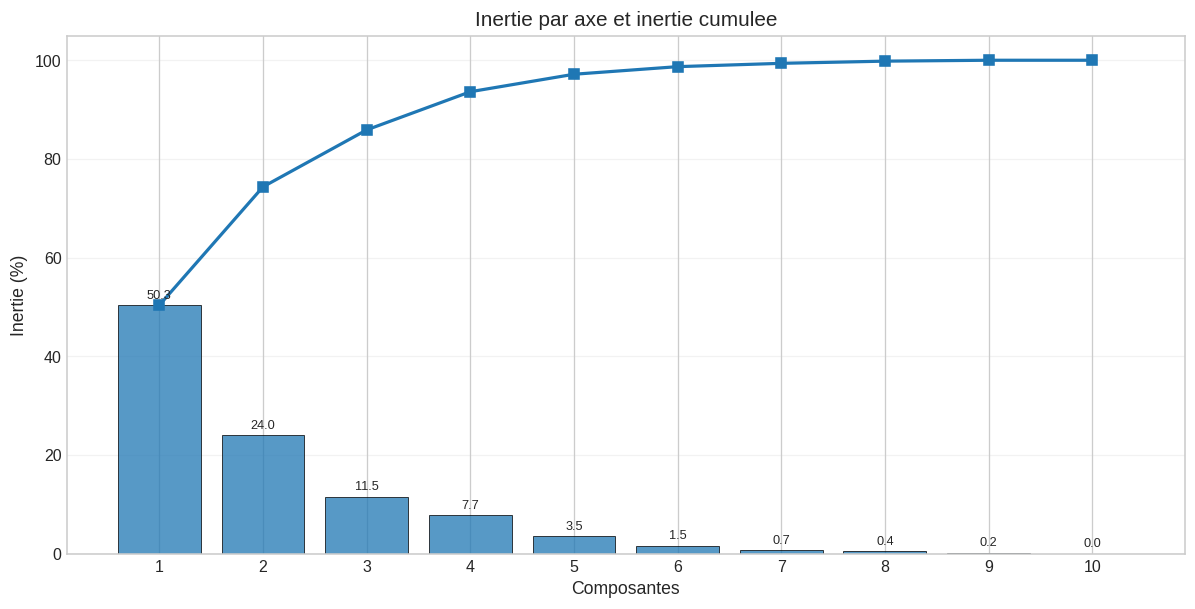

In [7]:
positions = np.arange(1, len(valeurs_propres) + 1)
fig, ax = plt.subplots(figsize=(10.5, 5.4))
barres = ax.bar(positions, part_inertie * 100, alpha=0.75, edgecolor="black", linewidth=0.6)
ax.plot(positions, inertie_cumulee * 100, marker="s", linewidth=2)
ax.set_xticks(positions)
ax.set_xlabel("Composantes")
ax.set_ylabel("Inertie (%)")
ax.set_title("Inertie par axe et inertie cumulee")
ax.grid(axis="y", alpha=0.25)
for rect, valeur in zip(barres, part_inertie * 100):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.8, f"{valeur:.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Projections des individus

In [8]:
scores = np.matmul(Z.to_numpy(), vecteurs_propres)
coord_indiv = pd.DataFrame(scores, index=boissons, columns=etiquettes_axes)
coord_indiv.iloc[:, :5].round(4)

,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
Boisson 1,-0.2694,1.7251,1.3454,-0.4357,0.3457
Boisson 2,-1.6773,1.3355,-0.1522,0.8385,0.4583
Boisson 3,1.7606,0.6852,-0.3359,1.1889,0.2759
Boisson 4,3.2043,0.3872,-1.6464,0.3526,-0.0767
Boisson 5,-1.8755,-0.5422,-0.0328,0.0928,0.6944
Boisson 6,-3.3383,0.0846,-0.9895,-1.1932,0.0808
Boisson 7,2.6959,0.6877,1.7159,-0.8059,-0.2159
Boisson 8,-2.1398,0.3438,0.2171,0.7197,-1.4714
Boisson 9,1.5965,-0.8961,-0.9957,-1.2861,-0.2372
Boisson 10,0.0430,-3.8107,0.8742,0.5285,0.1460


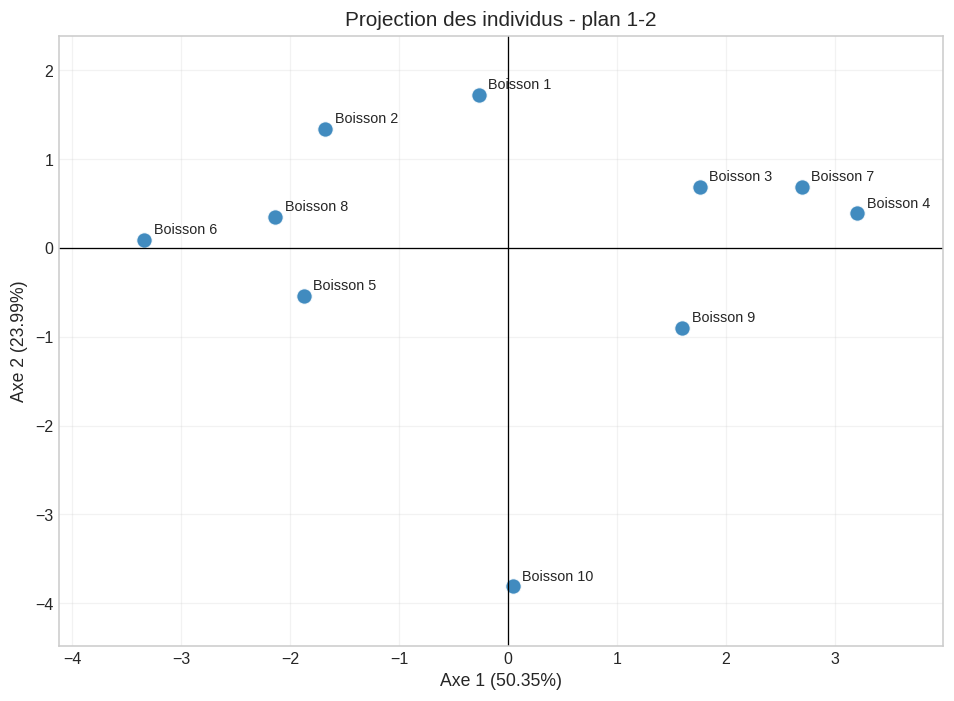

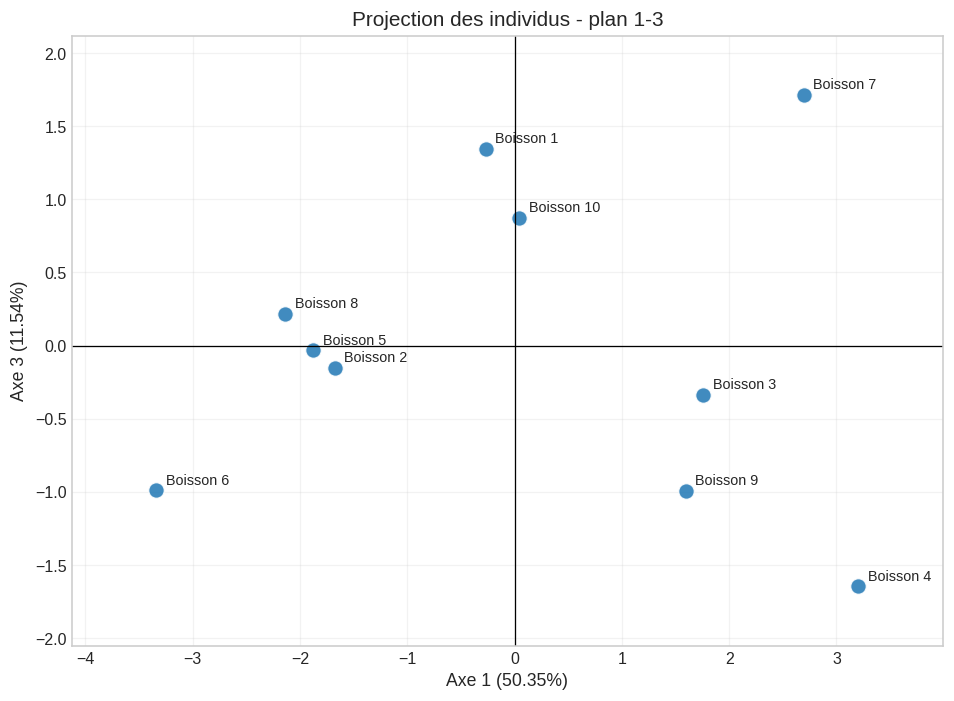

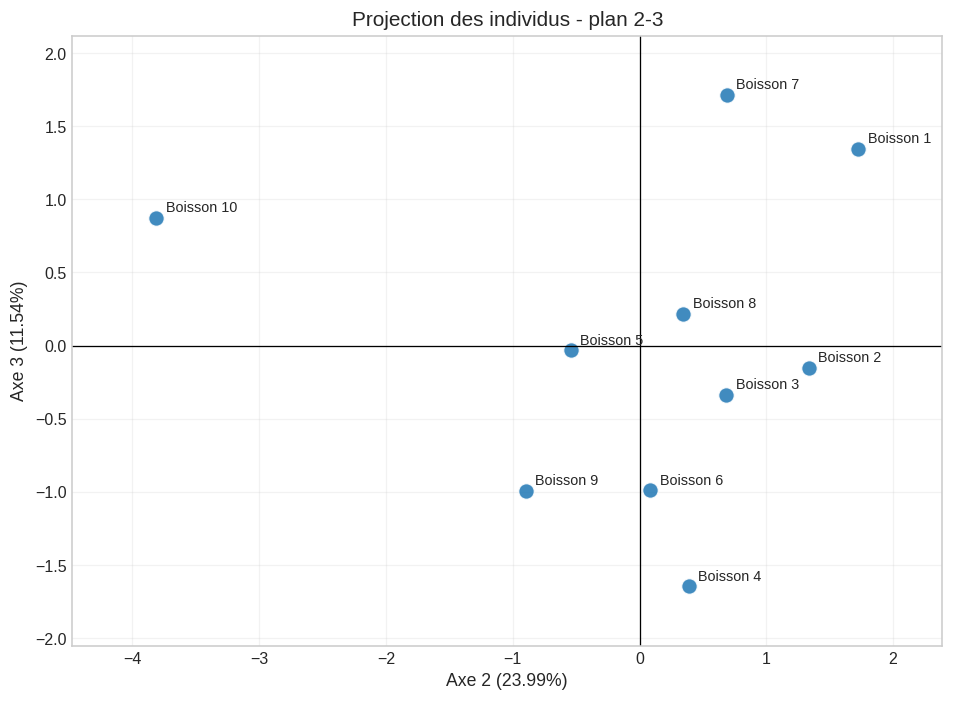

In [9]:
def tracer_individus(i, j, titre):
    fig, ax = plt.subplots(figsize=(8.4, 6.2))
    x_vals = scores[:, i]
    y_vals = scores[:, j]
    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.scatter(x_vals, y_vals, s=95, alpha=0.85, edgecolors="white", linewidths=0.8)
    for nom, x_pt, y_pt in zip(boissons, x_vals, y_vals):
        ax.annotate(nom, (x_pt, y_pt), xytext=(6, 4), textcoords="offset points", fontsize=9)
    ax.set_xlabel(f"Axe {i + 1} ({part_inertie[i] * 100:.2f}%)")
    ax.set_ylabel(f"Axe {j + 1} ({part_inertie[j] * 100:.2f}%)")
    ax.set_title(titre)
    ax.margins(0.12)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

tracer_individus(0, 1, "Projection des individus - plan 1-2")
tracer_individus(0, 2, "Projection des individus - plan 1-3")
tracer_individus(1, 2, "Projection des individus - plan 2-3")

## 7. Distances, qualites de representation et contributions des individus

In [10]:
dist2 = np.square(scores).sum(axis=1)
distance = np.sqrt(dist2)
valeurs_propres_sures = np.where(valeurs_propres > 1e-12, valeurs_propres, np.nan)

table_dist = pd.DataFrame({"Distance2": dist2, "Distance": distance}, index=boissons)

cos2_indiv = np.divide(np.square(scores), dist2[:, None])
table_cos2_indiv = pd.DataFrame(
    cos2_indiv[:, :3],
    index=boissons,
    columns=["cos2 Axe 1", "cos2 Axe 2", "cos2 Axe 3"]
)
table_cos2_indiv.insert(3, "Somme cos2 (1-3)", table_cos2_indiv.sum(axis=1))

contrib_indiv = np.divide(np.square(scores), (n - 1) * valeurs_propres_sures) * 100
table_contrib_indiv = pd.DataFrame(
    contrib_indiv[:, :3],
    index=boissons,
    columns=["Contrib Axe 1 (%)", "Contrib Axe 2 (%)", "Contrib Axe 3 (%)"]
)

print("Distances des individus")
display(table_dist.round(4))
print("Qualites de representation des individus")
display(table_cos2_indiv.round(4))
print("Contributions des individus")
display(table_contrib_indiv.round(2))

Distances des individus


,Distance2,Distance
Boisson 1,5.2914,2.3003
Boisson 2,5.9440,2.4380
Boisson 3,5.9143,2.4319
Boisson 4,13.5451,3.6804
Boisson 5,4.6724,2.1616
Boisson 6,13.7826,3.7125
Boisson 7,11.4847,3.3889
Boisson 8,7.4437,2.7283
Boisson 9,6.2709,2.5042
Boisson 10,15.6509,3.9561


Qualites de representation des individus


,cos2 Axe 1,cos2 Axe 2,cos2 Axe 3,Somme cos2 (1-3)
Boisson 1,0.0137,0.5624,0.3421,0.9182
Boisson 2,0.4733,0.3001,0.0039,0.7773
Boisson 3,0.5241,0.0794,0.0191,0.6226
Boisson 4,0.7580,0.0111,0.2001,0.9692
Boisson 5,0.7529,0.0629,0.0002,0.8160
Boisson 6,0.8086,0.0005,0.0710,0.8801
Boisson 7,0.6328,0.0412,0.2564,0.9304
Boisson 8,0.6151,0.0159,0.0063,0.6373
Boisson 9,0.4065,0.1281,0.1581,0.6927
Boisson 10,0.0001,0.9278,0.0488,0.9768


Contributions des individus


,Contrib Axe 1 (%),Contrib Axe 2 (%),Contrib Axe 3 (%)
Boisson 1,0.16,13.78,17.43
Boisson 2,6.21,8.26,0.22
Boisson 3,6.84,2.17,1.09
Boisson 4,22.66,0.69,26.10
Boisson 5,7.76,1.36,0.01
Boisson 6,24.59,0.03,9.43
Boisson 7,16.04,2.19,28.35
Boisson 8,10.10,0.55,0.45
Boisson 9,5.63,3.72,9.55
Boisson 10,0.00,67.24,7.36


## 8. Nouvelles variables, coordonnees, qualites et contributions

In [11]:
correlations_var_axes = vecteurs_propres * np.sqrt(valeurs_propres)
coord_var = pd.DataFrame(correlations_var_axes, index=variables, columns=etiquettes_axes)

cos2_var = np.square(correlations_var_axes)
table_cos2_var = pd.DataFrame(
    cos2_var[:, :3],
    index=variables,
    columns=["cos2 Axe 1", "cos2 Axe 2", "cos2 Axe 3"]
)
table_cos2_var.insert(3, "Somme cos2 (1-3)", table_cos2_var.sum(axis=1))

table_contrib_var = pd.DataFrame(
    np.square(vecteurs_propres[:, :3]) * 100,
    index=variables,
    columns=["Contrib Axe 1 (%)", "Contrib Axe 2 (%)", "Contrib Axe 3 (%)"]
)

print("Coordonnees des nouvelles variables")
display(coord_var.iloc[:, :5].round(4))
print("Qualites de representation des variables")
display(table_cos2_var.round(4))
print("Contributions des variables")
display(table_contrib_var.round(2))

Coordonnees des nouvelles variables


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
Fruite,0.9134,-0.3027,0.0603,-0.1256,0.1579
Sucre,0.8843,-0.1988,-0.0102,-0.1840,0.3500
Gout,-0.9113,0.0887,-0.2064,-0.0973,0.2806
Amer,-0.7357,-0.4320,-0.4015,-0.1479,0.0586
Piquant,-0.4323,0.7474,0.0180,0.4062,0.2815
Rugosite,-0.8291,-0.0000,-0.1128,-0.5375,0.0416
Odeur,-0.1344,-0.9666,-0.0387,0.1544,-0.0276
Acide,-0.3318,0.1233,0.8732,-0.3156,0.0274
Parfume,0.9303,0.1475,-0.1895,-0.1577,0.0910
Suffocant,-0.4230,-0.7376,0.3652,0.3010,0.1844


Qualites de representation des variables


,cos2 Axe 1,cos2 Axe 2,cos2 Axe 3,Somme cos2 (1-3)
Fruite,0.8343,0.0916,0.0036,0.9295
Sucre,0.7820,0.0395,0.0001,0.8217
Gout,0.8305,0.0079,0.0426,0.8809
Amer,0.5412,0.1866,0.1612,0.8890
Piquant,0.1869,0.5585,0.0003,0.7457
Rugosite,0.6874,0.0000,0.0127,0.7002
Odeur,0.0181,0.9343,0.0015,0.9539
Acide,0.1101,0.0152,0.7624,0.8877
Parfume,0.8654,0.0218,0.0359,0.9231
Suffocant,0.1789,0.5440,0.1334,0.8563


Contributions des variables


,Contrib Axe 1 (%),Contrib Axe 2 (%),Contrib Axe 3 (%)
Fruite,16.57,3.82,0.31
Sucre,15.53,1.65,0.01
Gout,16.50,0.33,3.69
Amer,10.75,7.78,13.97
Piquant,3.71,23.28,0.03
Rugosite,13.65,0.00,1.10
Odeur,0.36,38.94,0.13
Acide,2.19,0.63,66.08
Parfume,17.19,0.91,3.11
Suffocant,3.55,22.67,11.56


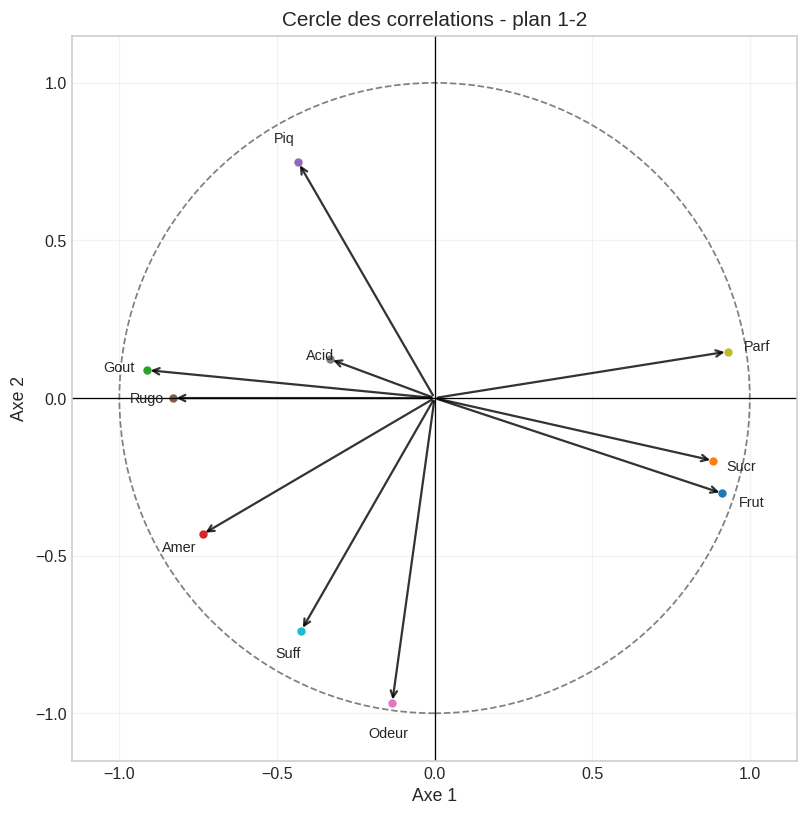

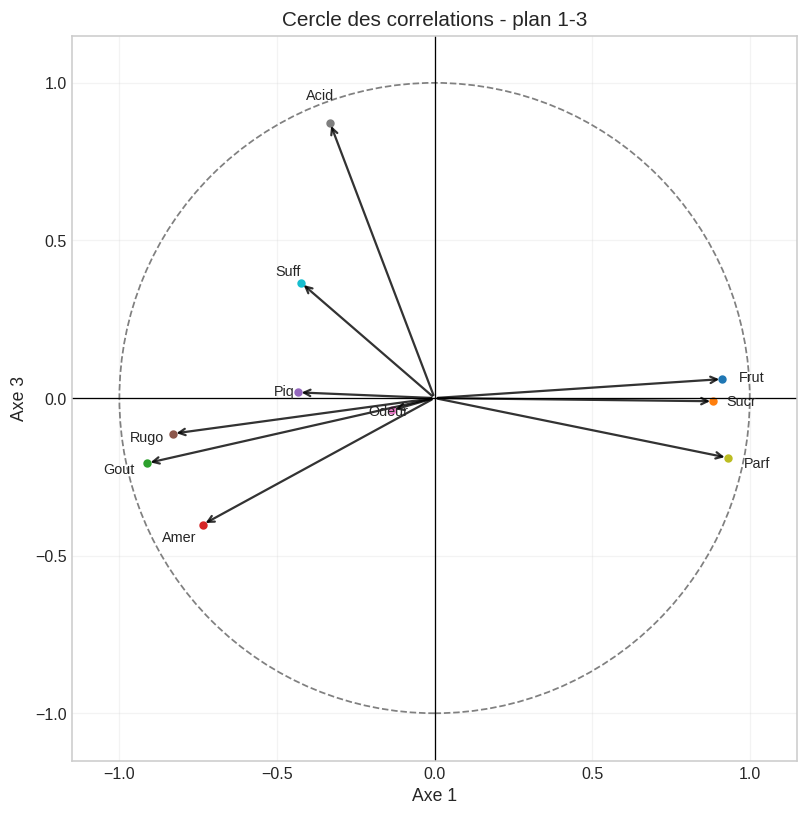

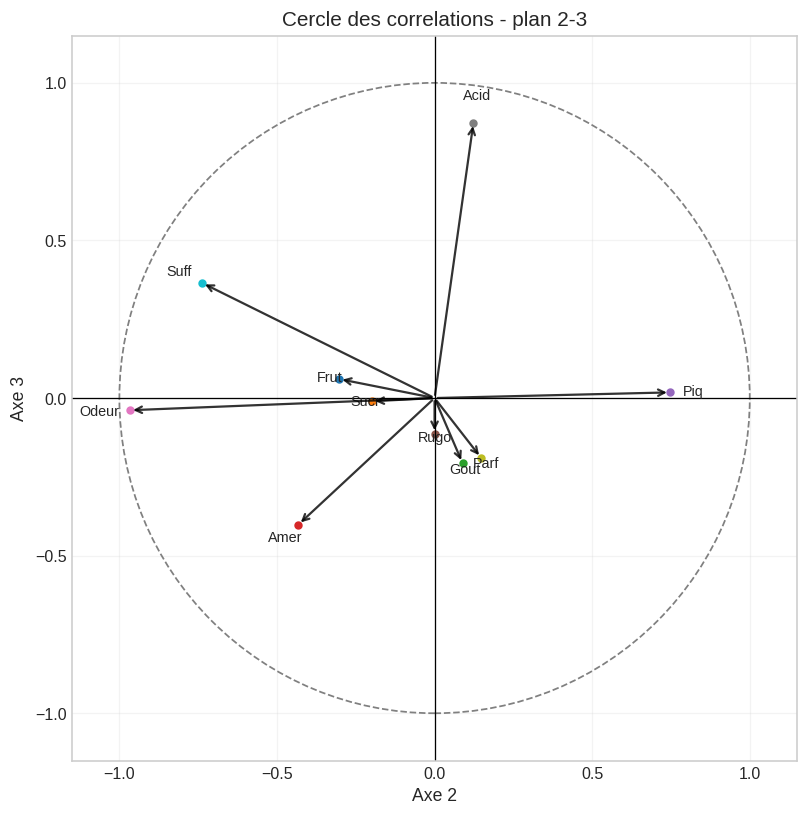

In [12]:
def tracer_cercle(i, j, titre):
    fig, ax = plt.subplots(figsize=(7.2, 7.2))
    contour = plt.Circle((0, 0), 1, fill=False, linestyle="--", linewidth=1.1, color="gray")
    ax.add_patch(contour)
    ax.axhline(y=0, color="black", linewidth=0.8)
    ax.axvline(x=0, color="black", linewidth=0.8)
    coord_x = correlations_var_axes[:, i]
    coord_y = correlations_var_axes[:, j]
    for nom, x_pt, y_pt in zip(variables_court, coord_x, coord_y):
        ax.annotate("", xy=(x_pt, y_pt), xytext=(0, 0), arrowprops={"arrowstyle": "->", "lw": 1.4, "alpha": 0.8})
        ax.scatter(x_pt, y_pt, s=18)
        ax.text(x_pt * 1.1, y_pt * 1.1, nom, fontsize=9, ha="center", va="center")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Axe {i + 1}")
    ax.set_ylabel(f"Axe {j + 1}")
    ax.set_title(titre)
    ax.grid(alpha=0.22)
    plt.tight_layout()
    plt.show()

tracer_cercle(0, 1, "Cercle des correlations - plan 1-2")
tracer_cercle(0, 2, "Cercle des correlations - plan 1-3")
tracer_cercle(1, 2, "Cercle des correlations - plan 2-3")

## 9. Interpretation selon chaque axe

In [13]:
def resume_extremes(serie, n=4):
    haut = [f"{nom} ({val:.3f})" for nom, val in serie.sort_values(ascending=False).head(n).items()]
    bas = [f"{nom} ({val:.3f})" for nom, val in serie.sort_values().head(n).items()]
    return haut, bas

for axe in ["Axe 1", "Axe 2", "Axe 3"]:
    v_pos, v_neg = resume_extremes(coord_var[axe])
    b_pos, b_neg = resume_extremes(coord_indiv[axe])
    print() 
    print(axe)
    print("Variables - pole positif :", v_pos)
    print("Variables - pole negatif :", v_neg)
    print("Boissons - pole positif :", b_pos)
    print("Boissons - pole negatif :", b_neg)


Axe 1
Variables - pole positif : ['Parfume (0.930)', 'Fruite (0.913)', 'Sucre (0.884)', 'Odeur (-0.134)']
Variables - pole negatif : ['Gout (-0.911)', 'Rugosite (-0.829)', 'Amer (-0.736)', 'Piquant (-0.432)']
Boissons - pole positif : ['Boisson 4 (3.204)', 'Boisson 7 (2.696)', 'Boisson 3 (1.761)', 'Boisson 9 (1.597)']
Boissons - pole negatif : ['Boisson 6 (-3.338)', 'Boisson 8 (-2.140)', 'Boisson 5 (-1.876)', 'Boisson 2 (-1.677)']

Axe 2
Variables - pole positif : ['Piquant (0.747)', 'Parfume (0.148)', 'Acide (0.123)', 'Gout (0.089)']
Variables - pole negatif : ['Odeur (-0.967)', 'Suffocant (-0.738)', 'Amer (-0.432)', 'Fruite (-0.303)']
Boissons - pole positif : ['Boisson 1 (1.725)', 'Boisson 2 (1.336)', 'Boisson 7 (0.688)', 'Boisson 3 (0.685)']
Boissons - pole negatif : ['Boisson 10 (-3.811)', 'Boisson 9 (-0.896)', 'Boisson 5 (-0.542)', 'Boisson 6 (0.085)']

Axe 3
Variables - pole positif : ['Acide (0.873)', 'Suffocant (0.365)', 'Fruite (0.060)', 'Piquant (0.018)']
Variables - pole n

### Interpretation redigee

**Axe 1 (`50.35%`)**

L'axe 1 oppose nettement:

- un pole `fruite - sucre - parfume`
- a un pole `gout - rugosite - amertume`

Interpretation:

- les boissons situees du cote positif sont plus douces, plus agreables au nez et davantage marquees par le fruit et le parfum
- les boissons situees du cote negatif ont un profil plus rugueux, avec plus de corps gustatif et davantage d'amertume

Boissons proches sur cet axe:

- `Boisson 4`, `Boisson 7`, `Boisson 3` et `Boisson 9` se ressemblent par leur caractere fruite, sucre et parfume
- `Boisson 6`, `Boisson 8`, `Boisson 5` et `Boisson 2` se ressemblent par un profil moins fruite et plus rude

**Axe 2 (`23.99%`)**

L'axe 2 oppose:

- un pole `odeur forte - suffocant`
- a un pole `piquant`

Interpretation:

- les boissons du pole positif ont une intensite olfactive tres forte et peuvent etre ressenties comme plus lourdes ou plus suffocantes
- les boissons du pole negatif sont davantage associees a une sensation piquante

Boisson remarquable:

- `Boisson 10` est la plus typique de cet axe et se distingue fortement des autres

**Axe 3 (`11.54%`)**

L'axe 3 oppose:

- un pole `acide`
- a un pole `amer`

Interpretation:

- les boissons du pole positif sont davantage caracterisees par l'acidite
- les boissons du pole negatif sont plus marquees par l'amertume et un gout plus soutenu

Boissons proches sur cet axe:

- `Boisson 7` et `Boisson 1` sont proches par leur acidite
- `Boisson 4`, `Boisson 9` et `Boisson 6` se rapprochent d'un profil plus amer et moins acide


## 10. Points communs entre les boissons

On peut regrouper les boissons en grands profils:

- **Groupe fruit-sucre-parfum**: `Boissons 4, 7, 3, 9`
- **Groupe moins fruite, plus rugueux**: `Boissons 6, 8, 5, 2`
- **Profil odorant et suffocant**: `Boisson 10`
- **Profil intermediaire mais plutot acide**: `Boisson 1`

Les rapprochements les plus defendables sont donc:

- `Boisson 4` et `Boisson 7`: tres proches du pole fruit-sucre-parfum
- `Boisson 6` et `Boisson 8`: proches d'un profil plus rude et moins fruite
- `Boisson 1` et `Boisson 7`: rapprochement par la composante acide
- `Boisson 10`: boisson la plus atypique a cause de l'odeur et du caractere suffocant


## 11. Export des tableaux utiles

In [14]:
exports = {
    "05_matrice_R_correlations.csv": R.round(4),
    "06_tableau_taux_inertie.csv": table_inertie.round(4),
    "07_coordonnees_individus.csv": coord_indiv.round(4),
    "08_distances_individus.csv": table_dist.round(4),
    "09_cos2_individus.csv": table_cos2_indiv.round(4),
    "10_contributions_individus.csv": table_contrib_indiv.round(2),
    "11_coordonnees_variables.csv": coord_var.round(4),
    "12_cos2_variables.csv": table_cos2_var.round(4),
    "13_contributions_variables.csv": table_contrib_var.round(2)
}

for nom_fichier, tableau in exports.items():
    tableau.to_csv(dossier_sortie / nom_fichier, encoding="utf-8-sig")

print(f"Fichiers exportes dans : {dossier_sortie}")

Fichiers exportes dans : /outputs_tp3_boissons
